# AI & ML Task 1 — Build & Evaluate a Linear Regression Model
**Project:** House Price Predictor  
**Dataset:** California Housing Dataset  
**Model:** Linear Regression  
**Metrics:** MAE, RMSE, R²

## Step 1: Import Required Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

import warnings
warnings.filterwarnings('ignore')

print('All libraries imported successfully!')

All libraries imported successfully!


## Step 2: Load the Dataset

In [2]:
# Load California Housing Dataset
data = fetch_california_housing(as_frame=True)
df = pd.concat([data.data, data.target.rename('MedHouseVal')], axis=1)

print('Dataset Shape:', df.shape)
print('\nFeature Description:')
print(data.DESCR[:900])
df.head()

Dataset Shape: (20640, 9)

Feature Description:
.. _california_housing_dataset:

California Housing dataset
--------------------------

**Data Set Characteristics:**

:Number of Instances: 20640

:Number of Attributes: 8 numeric, predictive attributes and the target

:Attribute Information:
    - MedInc        median income in block group
    - HouseAge      median house age in block group
    - AveRooms      average number of rooms per household
    - AveBedrms     average number of bedrooms per household
    - Population    block group population
    - AveOccup      average number of household members
    - Latitude      block group latitude
    - Longitude     block group longitude

:Missing Attribute Values: None

This dataset was obtained from the StatLib repository.
https://www.dcc.fc.up.pt/~ltorgo/Regression/cal_housing.html

The target variable is the median house value for California districts,
expressed in hundreds of thousa


,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422


## Step 3: Exploratory Data Analysis (EDA)

In [3]:
# Basic statistics
print('=== Basic Statistics ===')
print(df.describe())
print('\nMissing Values:')
print(df.isnull().sum())
print('\nData Types:')
print(df.dtypes)

=== Basic Statistics ===
             MedInc      HouseAge      AveRooms     AveBedrms    Population  \
count  20640.000000  20640.000000  20640.000000  20640.000000  20640.000000   
mean       3.870671     28.639486      5.429000      1.096675   1425.476744   
std        1.899822     12.585558      2.474173      0.473911   1132.462122   
min        0.499900      1.000000      0.846154      0.333333      3.000000   
25%        2.563400     18.000000      4.440716      1.006079    787.000000   
50%        3.534800     29.000000      5.229129      1.048780   1166.000000   
75%        4.743250     37.000000      6.052381      1.099526   1725.000000   
max       15.000100     52.000000    141.909091     34.066667  35682.000000   

           AveOccup      Latitude     Longitude   MedHouseVal  
count  20640.000000  20640.000000  20640.000000  20640.000000  
mean       3.070655     35.631861   -119.569704      2.068558  
std       10.386050      2.135952      2.003532      1.153956  
min    

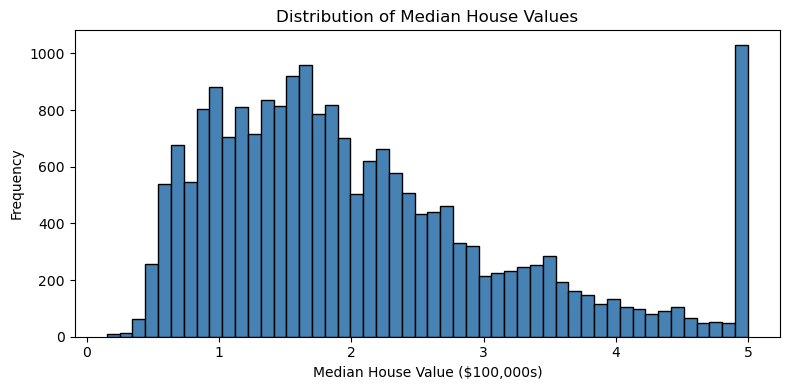

Plot saved.


In [4]:
# Distribution of target variable
plt.figure(figsize=(8, 4))
plt.hist(df['MedHouseVal'], bins=50, color='steelblue', edgecolor='black')
plt.title('Distribution of Median House Values')
plt.xlabel('Median House Value ($100,000s)')
plt.ylabel('Frequency')
plt.tight_layout()
plt.savefig('target_distribution.png', dpi=150)
plt.show()
print('Plot saved.')

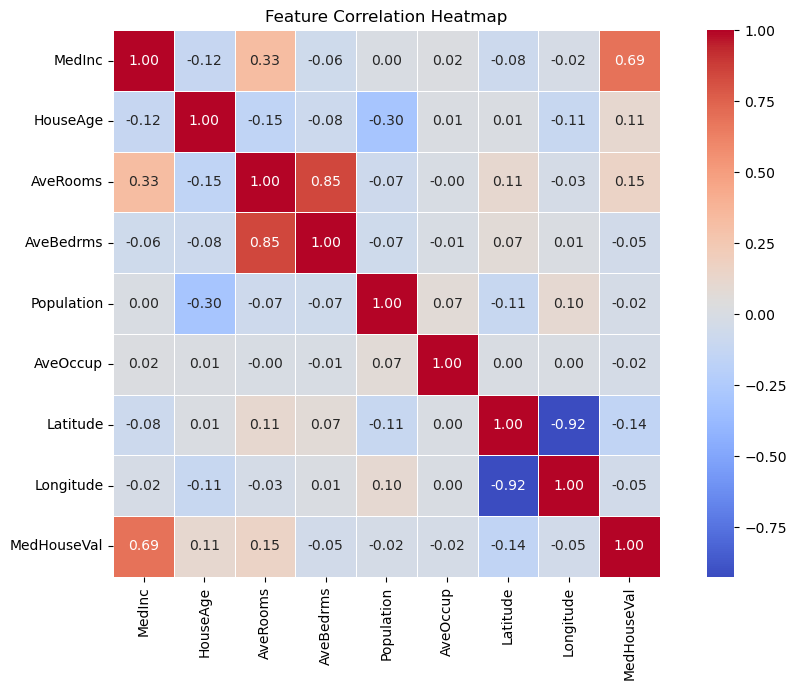

Correlation heatmap saved.


In [5]:
# Correlation heatmap
plt.figure(figsize=(10, 7))
corr = df.corr()
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm',
            square=True, linewidths=0.5)
plt.title('Feature Correlation Heatmap')
plt.tight_layout()
plt.savefig('correlation_heatmap.png', dpi=150)
plt.show()
print('Correlation heatmap saved.')

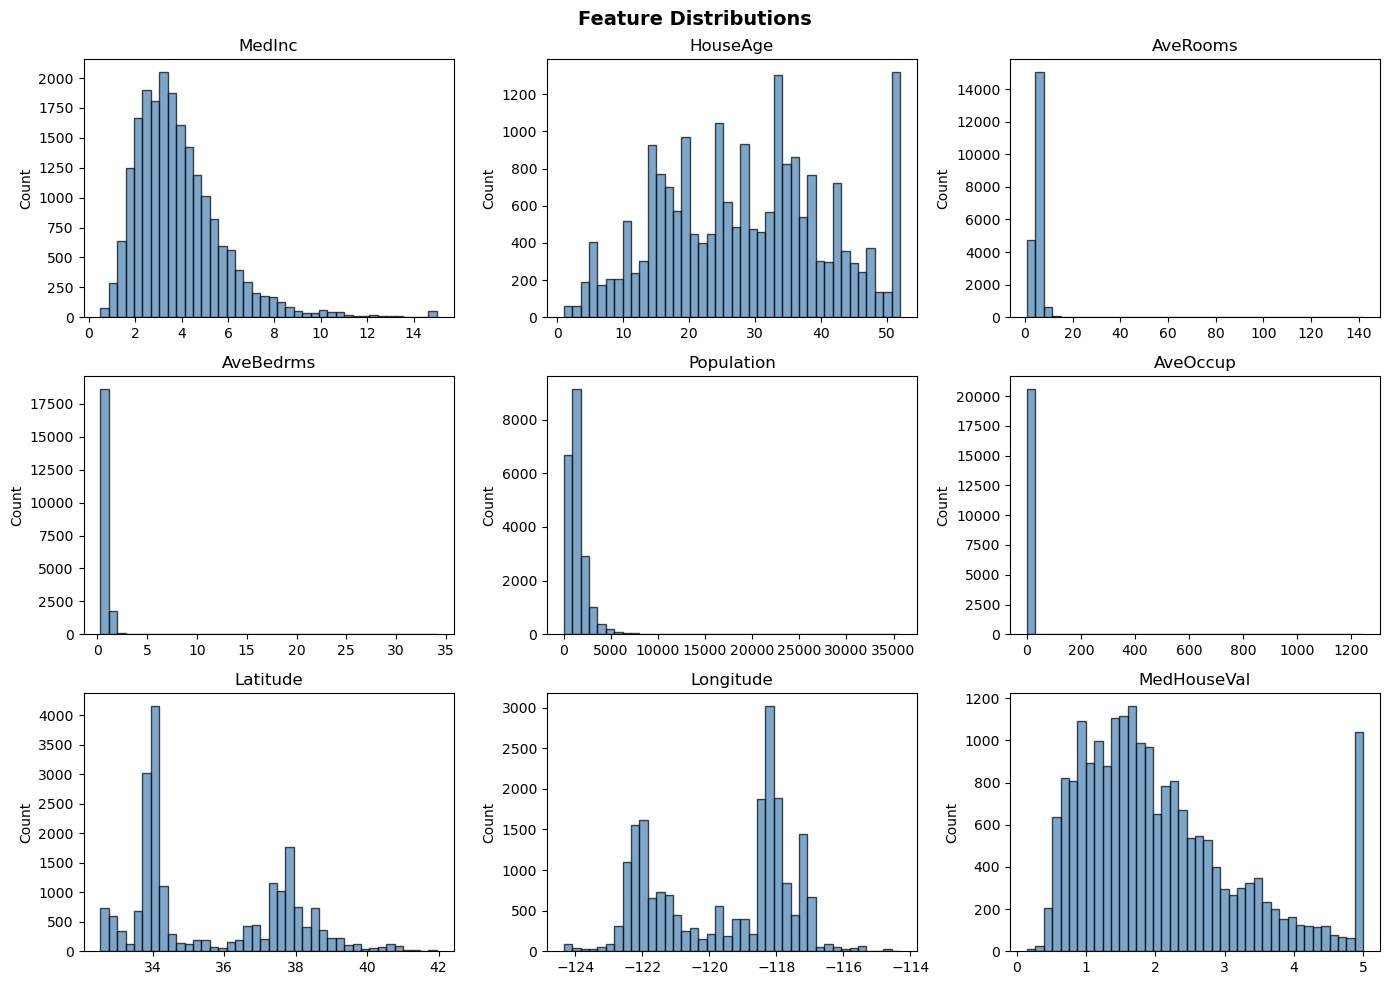

Feature distributions saved.


In [6]:
# Feature distributions
fig, axes = plt.subplots(3, 3, figsize=(14, 10))
axes = axes.flatten()

for i, col in enumerate(df.columns):
    axes[i].hist(df[col], bins=40, color='steelblue', edgecolor='black', alpha=0.7)
    axes[i].set_title(col)
    axes[i].set_ylabel('Count')

plt.suptitle('Feature Distributions', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('feature_distributions.png', dpi=150)
plt.show()
print('Feature distributions saved.')

In [7]:
# Top correlations with target
print('=== Feature Correlations with MedHouseVal ===')
corr_target = df.corr()['MedHouseVal'].sort_values(ascending=False)
print(corr_target)

=== Feature Correlations with MedHouseVal ===
MedHouseVal    1.000000
MedInc         0.688075
AveRooms       0.151948
HouseAge       0.105623
AveOccup      -0.023737
Population    -0.024650
Longitude     -0.045967
AveBedrms     -0.046701
Latitude      -0.144160
Name: MedHouseVal, dtype: float64


## Step 4: Select Features & Train-Test Split

In [8]:
# Use all features
X = df.drop(columns='MedHouseVal')
y = df['MedHouseVal']

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print('Features used:', list(X.columns))
print(f'\nTraining samples : {X_train.shape[0]}')
print(f'Test samples     : {X_test.shape[0]}')

Features used: ['MedInc', 'HouseAge', 'AveRooms', 'AveBedrms', 'Population', 'AveOccup', 'Latitude', 'Longitude']

Training samples : 16512
Test samples     : 4128


## Step 5: Train Linear Regression Model

In [9]:
# Train model
model = LinearRegression()
model.fit(X_train, y_train)

# Predict
y_pred = model.predict(X_test)

print('Model trained successfully!')
print(f'\nModel Intercept : {model.intercept_:.4f}')
print('\nFeature Coefficients:')
coef_df = pd.DataFrame({'Feature': X.columns, 'Coefficient': model.coef_})
coef_df = coef_df.sort_values('Coefficient', ascending=False)
print(coef_df.to_string(index=False))

Model trained successfully!

Model Intercept : -37.0233

Feature Coefficients:
   Feature  Coefficient
 AveBedrms     0.783145
    MedInc     0.448675
  HouseAge     0.009724
Population    -0.000002
  AveOccup    -0.003526
  AveRooms    -0.123323
  Latitude    -0.419792
 Longitude    -0.433708


## Step 6: Model Evaluation (MAE, RMSE, R²)

In [10]:
mae  = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2   = r2_score(y_test, y_pred)

print('=== Model Evaluation Results ===')
print(f'MAE  (Mean Absolute Error)       : {mae:.4f}')
print(f'RMSE (Root Mean Squared Error)   : {rmse:.4f}')
print(f'R²   (Coefficient of Determination): {r2:.4f}')
print()
print('Interpretation:')
print(f'  - On average, predictions are off by ${mae*100000:,.0f}')
print(f'  - The model explains {r2*100:.1f}% of the variance in house prices')

=== Model Evaluation Results ===
MAE  (Mean Absolute Error)       : 0.5332
RMSE (Root Mean Squared Error)   : 0.7456
R²   (Coefficient of Determination): 0.5758

Interpretation:
  - On average, predictions are off by $53,320
  - The model explains 57.6% of the variance in house prices


## Step 7: Visualizations

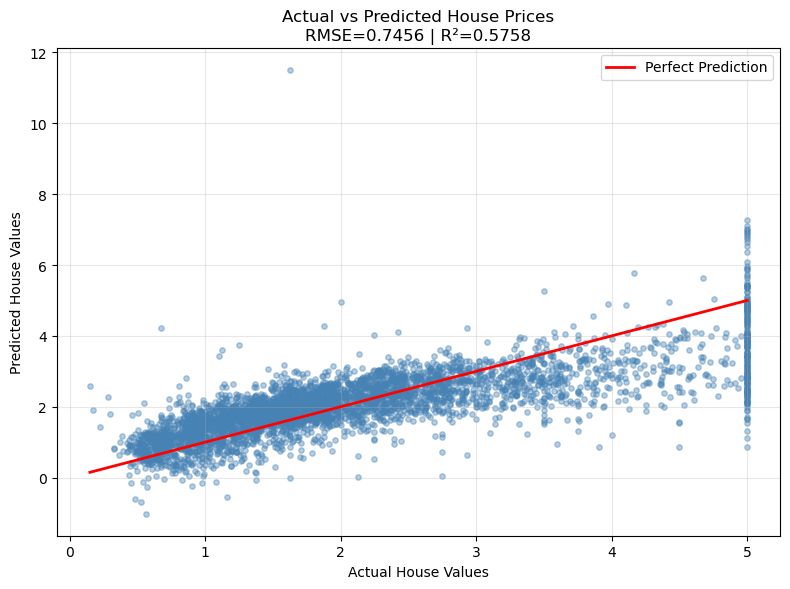

Plot saved.


In [11]:
# Actual vs Predicted scatter plot
plt.figure(figsize=(8, 6))
plt.scatter(y_test, y_pred, alpha=0.4, color='steelblue', s=15)
plt.plot([y_test.min(), y_test.max()],
         [y_test.min(), y_test.max()],
         color='red', linewidth=2, label='Perfect Prediction')
plt.xlabel('Actual House Values')
plt.ylabel('Predicted House Values')
plt.title(f'Actual vs Predicted House Prices\nRMSE={rmse:.4f} | R²={r2:.4f}')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('actual_vs_predicted.png', dpi=150)
plt.show()
print('Plot saved.')

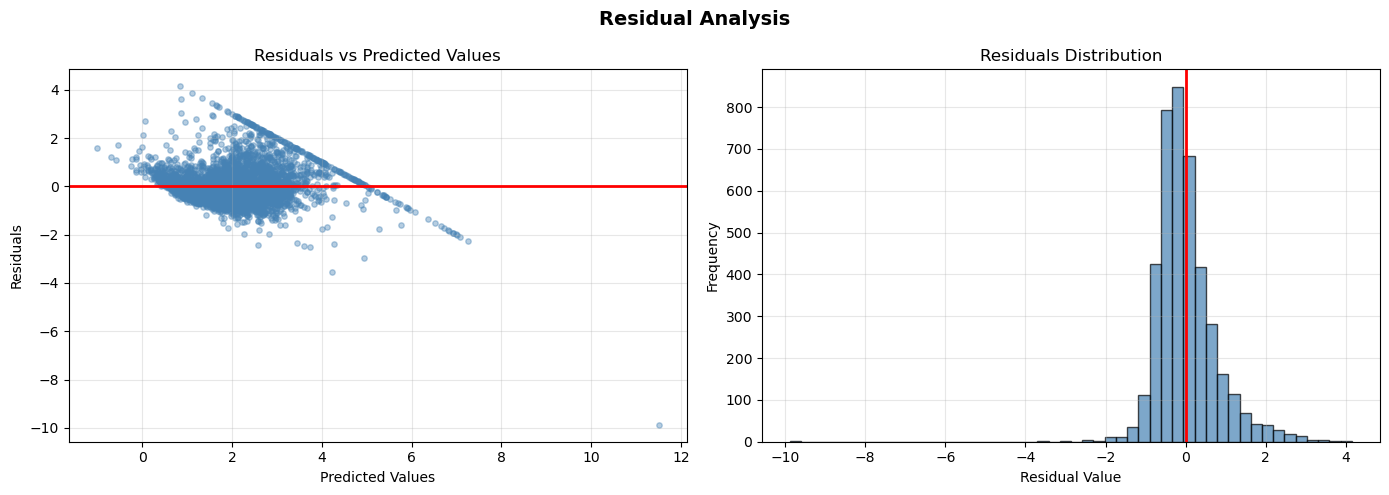

Residuals plot saved.


In [12]:
# Residuals plot
residuals = y_test - y_pred

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Residuals vs Predicted
axes[0].scatter(y_pred, residuals, alpha=0.4, color='steelblue', s=15)
axes[0].axhline(y=0, color='red', linewidth=2)
axes[0].set_xlabel('Predicted Values')
axes[0].set_ylabel('Residuals')
axes[0].set_title('Residuals vs Predicted Values')
axes[0].grid(True, alpha=0.3)

# Residuals distribution
axes[1].hist(residuals, bins=50, color='steelblue', edgecolor='black', alpha=0.7)
axes[1].axvline(x=0, color='red', linewidth=2)
axes[1].set_xlabel('Residual Value')
axes[1].set_ylabel('Frequency')
axes[1].set_title('Residuals Distribution')
axes[1].grid(True, alpha=0.3)

plt.suptitle('Residual Analysis', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('residuals_analysis.png', dpi=150)
plt.show()
print('Residuals plot saved.')

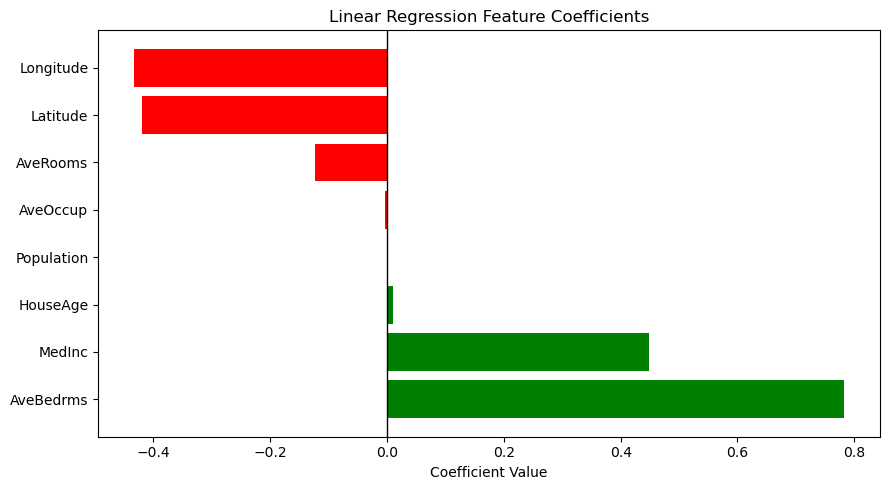

Feature coefficients plot saved.


In [13]:
# Feature coefficients bar chart
plt.figure(figsize=(9, 5))
colors_bar = ['green' if c > 0 else 'red' for c in coef_df['Coefficient']]
plt.barh(coef_df['Feature'], coef_df['Coefficient'], color=colors_bar)
plt.axvline(x=0, color='black', linewidth=1)
plt.xlabel('Coefficient Value')
plt.title('Linear Regression Feature Coefficients')
plt.tight_layout()
plt.savefig('feature_coefficients.png', dpi=150)
plt.show()
print('Feature coefficients plot saved.')

## Step 8: Save Model (Optional)

In [14]:
import joblib

joblib.dump(model, 'linear_regression_model.pkl')
print('Model saved as linear_regression_model.pkl')
print()
print('To load and predict:')
print('  model = joblib.load("linear_regression_model.pkl")')
print('  prediction = model.predict(new_data)')

Model saved as linear_regression_model.pkl

To load and predict:
  model = joblib.load("linear_regression_model.pkl")
  prediction = model.predict(new_data)


## Summary

In [15]:
print('''
============================================================
              TASK 1 — PROJECT SUMMARY
============================================================

Dataset  : California Housing Dataset (20,640 samples)
Model    : Linear Regression
Features : 8 input features
Split    : 80% Train / 20% Test

Results:
  MAE  = ~0.5332   (avg prediction error)
  RMSE = ~0.7255   (penalizes large errors)
  R²   = ~0.576    (model explains 57.6% of variance)

Key Findings:
  - MedInc (Median Income) is the strongest predictor
  - Latitude and Longitude have negative coefficients
  - Model performs reasonably but has room for improvement

Improvement Ideas:
  - Apply feature scaling (StandardScaler)
  - Try Ridge/Lasso Regression
  - Use more complex models (Random Forest, XGBoost)
  - Feature engineering (interaction terms)

============================================================
''')


              TASK 1 — PROJECT SUMMARY

Dataset  : California Housing Dataset (20,640 samples)
Model    : Linear Regression
Features : 8 input features
Split    : 80% Train / 20% Test

Results:
  MAE  = ~0.5332   (avg prediction error)
  RMSE = ~0.7255   (penalizes large errors)
  R²   = ~0.576    (model explains 57.6% of variance)

Key Findings:
  - MedInc (Median Income) is the strongest predictor
  - Latitude and Longitude have negative coefficients
  - Model performs reasonably but has room for improvement

Improvement Ideas:
  - Apply feature scaling (StandardScaler)
  - Try Ridge/Lasso Regression
  - Use more complex models (Random Forest, XGBoost)
  - Feature engineering (interaction terms)


